In [1]:
from google.colab import files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install git+https://github.com/kratzert/RRMPG.git

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
import random
from datetime import datetime, timedelta
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from rrmpg.models import GR4J
import os
import zipfile
from scipy.optimize import minimize

from google.colab import files
from numba import njit

In [5]:
# ==============================
# ZIP file paths
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Temporary extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files and locate the CSV path
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted to {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extract ZIP files
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 official stations
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (SILO ET)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]
print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset to common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final check
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ ZIP extracted to /content/05_hydro
✅ ZIP extracted to /content/03_streamflow
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


In [6]:
import numpy as np

# =============================================================
# 📌 COMPUTE RR
# =============================================================
RR = []
stations_list = []

start_date = "1980-01-01"
end_date = "2014-12-31"

for st in common_stations:
    P = precip[st].loc[start_date:end_date].to_numpy(float)
    Qs = Q[st].loc[start_date:end_date].to_numpy(float)

    mask = (~np.isnan(P)) & (~np.isnan(Qs))

    if mask.sum() == 0 or np.nansum(P[mask]) <= 0:
        RR.append(np.nan)
    else:
        RR.append(np.nansum(Qs[mask]) / np.nansum(P[mask]))

    stations_list.append(st)

RR = np.array(RR)
stations = np.array(stations_list)

# =============================================================
# 📌 CLEAN
# =============================================================
mask = np.isfinite(RR)
RR = RR[mask]
stations = stations[mask]

# =============================================================
# 📌 PERCENTILES
# =============================================================
p10 = np.percentile(RR, 10)
p50 = np.percentile(RR, 50)
p60 = np.percentile(RR, 60)
p90 = np.percentile(RR, 90)

# =============================================================
# 📌 SELECT CLASSES
# =============================================================
dry_mask = RR <= p10
mid_mask = (RR >= p50) & (RR <= p60)
wet_mask = RR >= p90

dry_stations_all = stations[dry_mask]
mid_stations_all = stations[mid_mask]
wet_stations_all = stations[wet_mask]

dry_RR_all = RR[dry_mask]
mid_RR_all = RR[mid_mask]
wet_RR_all = RR[wet_mask]

# =============================================================
# 📌 SORT INSIDE EACH CLASS (IMPORTANT)
# =============================================================
def sort_pair(st, rr):
    order = np.argsort(rr)
    return st[order], rr[order]

dry_stations_all, dry_RR_all = sort_pair(dry_stations_all, dry_RR_all)
mid_stations_all, mid_RR_all = sort_pair(mid_stations_all, mid_RR_all)
wet_stations_all, wet_RR_all = sort_pair(wet_stations_all, wet_RR_all)

# =============================================================
# 📌 FIXED SIZE SAMPLING
# =============================================================
dry_n = 23
mid_n = 22
wet_n = 22

assert len(dry_stations_all) >= dry_n, "Not enough dry basins"
assert len(mid_stations_all) >= mid_n, "Not enough mid basins"
assert len(wet_stations_all) >= wet_n, "Not enough wet basins"

dry_stations = dry_stations_all[:dry_n]
dry_RR = dry_RR_all[:dry_n]

mid_stations = mid_stations_all[:mid_n]
mid_RR = mid_RR_all[:mid_n]

wet_stations = wet_stations_all[:wet_n]
wet_RR = wet_RR_all[:wet_n]

# =============================================================
# 📌 FINAL CHECK
# =============================================================
print("🟤 Dry:", len(dry_stations))
print("🟡 Mid:", len(mid_stations))
print("🔵 Wet:", len(wet_stations))

# =============================================================
# 📌 OUTPUT
# =============================================================
RR_classes = {
    "dry_0_10": {"stations": dry_stations, "RR": dry_RR},
    "mid_50_60": {"stations": mid_stations, "RR": mid_RR},
    "wet_90_100": {"stations": wet_stations, "RR": wet_RR},
}

🟤 Dry: 23
🟡 Mid: 22
🔵 Wet: 22


In [7]:
# =============================================================
# 📌 DISPLAY RR RANGES
# =============================================================
def print_range(name, rr_values):
    print(f"{name} RR range: [{np.min(rr_values):.4f} , {np.max(rr_values):.4f}]")

print("\n===== RR RANGES =====")
print_range("🟤 Dry (0–10%)", dry_RR)
print_range("🟡 Mid (50–60%)", mid_RR)
print_range("🔵 Wet (90–100%)", wet_RR)


===== RR RANGES =====
🟤 Dry (0–10%) RR range: [0.0060 , 0.0659]
🟡 Mid (50–60%) RR range: [0.1838 , 0.2306]
🔵 Wet (90–100%) RR range: [0.4444 , 0.7955]


GR4J

In [8]:
print(type(dry_stations), dry_stations[:3])
print(type(mid_stations), mid_stations[:3])
print(type(wet_stations), wet_stations[-2:])

<class 'numpy.ndarray'> ['616002' '616013' 'A2390523']
<class 'numpy.ndarray'> ['G8110016' 'A5040523' '212260']
<class 'numpy.ndarray'> ['308799' '113004A']


In [ ]:
# ============================================
# General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1.0


#stations = np.concatenate([
#    dry_stations,
#    mid_stations,
#    wet_stations
#]).tolist()

stations = common_stations

results_GR4J = {}

# Directory to save simulated series
output_dir = "/content/GR4J_Qsim_val"
os.makedirs(output_dir, exist_ok=True)

# ============================================
# Metric functions (NaNs ignored)
# ============================================

def NSE(obs, sim):
    df = pd.DataFrame({"obs": obs, "sim": sim}).dropna()
    if df.empty or df["obs"].var() == 0:
        return np.nan
    return 1 - np.sum((df["sim"] - df["obs"])**2) / np.sum(
        (df["obs"] - df["obs"].mean())**2
    )

def NNSE(obs, sim):
    nse = NSE(obs, sim)
    return 1 / (2 - nse) if not np.isnan(nse) else np.nan

# ============================================
# Runoff Ratio
# ============================================
def runoff_ratio(Q, P):
    df = pd.DataFrame({"Q": Q, "P": P}).dropna()
    if df.empty or df["P"].sum() == 0:
        return np.nan
    return df["Q"].sum() / df["P"].sum()

# ============================================
# GR4J objective function
# ============================================
def objective_gr4j(x, Q, P, ET):
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), x))
    model.set_params(params)
    try:
        Qsim = model.simulate(P, ET).flatten()
        nse = NSE(Q, Qsim)
        return 1 - nse if np.isfinite(nse) else 1e6
    except Exception:
        return 1e6

# ============================================
# GR4J parameter bounds
# ============================================
bounds = [
    (1, 3200),    # x1
    (-15, 15),    # x2
    (1, 1000),    # x3
    (0.5, 5)      # x4
]

# ============================================
# Main loop over basins
# ============================================
for i, station_id in enumerate(stations, start=1):

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    ET = et[station_id].loc[start_date:end_date].to_numpy(float)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data)")
        continue

    missing_ratio = np.isnan(Q_obs).sum() / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too much missing data ({missing_ratio*100:.1f}%)")
        continue

    # Runoff Ratio
    RR = runoff_ratio(Q_obs, P)

    # Calibration / validation split
    b1 = int(N * b1_ratio)
    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # Multi-start calibration
    best_fun = np.inf
    best_x = None
    np.random.seed(42)
    for _ in range(10):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]
        res = minimize(
            objective_gr4j,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 3000}
        )
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        print("⚠️ Calibration failed")
        continue

    # Final simulation
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), best_x))
    model.set_params(params)

    Qsim_val = model.simulate(P_val, ET_val).flatten()

    # Metrics
    nse_cal = NSE(Q_cal, model.simulate(P_cal, ET_cal).flatten())
    nnse_cal = NNSE(Q_cal, model.simulate(P_cal, ET_cal).flatten())
    nse_val = NSE(Q_val, Qsim_val)
    nnse_val = NNSE(Q_val, Qsim_val)

    # Storage
    results_GR4J[station_id] = {
      "RR": RR,
      "NSE_cal": nse_cal,
      "NNSE_cal": nnse_cal,
      "NSE_val": nse_val,
      "NNSE_val": nnse_val,
      "params": params,
      "Qsim_val": Qsim_val
    }

    # Save CSV + download validation-only data
    df_Qsim_val = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D")[b1:],
        "Qsim_val": Qsim_val
    })
    file_path = os.path.join(output_dir, f"Qsim_val_GR4J_{station_id}.csv")
    df_Qsim_val.to_csv(file_path, index=False)
    #print(f"✅ Saved -> {file_path}")

print(f"\n✅ Finished: {len(results_GR4J)} basins calibrated and downloaded")


##GRHyMoLAP

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from numba import njit

# ============================================
# General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1

stations = common_stations
results_GRHyMoLAP = {}

# ============================================
# Metrics definitions
# ============================================
@njit
def NSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.var(obs) == 0:
        return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)

@njit
def NNSE(nse):
    if np.isnan(nse):
        return np.nan
    return 1.0 / (2.0 - nse)

@njit
def RMSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((sim - obs)**2))

@njit
def PBIAS(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return  np.sum(sim - obs) / np.sum(obs)

@njit
def FHV(obs, sim, top_fraction=0.02):
    epsilon = 0
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_top = int(len(obs) * top_fraction)
    if n_top == 0:
        return np.nan
    idx = np.argsort(obs)[-n_top:]
    obs_top = obs[idx]
    sim_top = sim[idx]
    return  np.sum(sim_top - obs_top) / (np.sum(obs_top) + epsilon)

@njit
def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)

# ============================================
# Percolation function
# ============================================
@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    S[0] = X1 / 2
    Perc = np.zeros(n)
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))
    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2
        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))
        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))
        S[i] = S[i-1] + Ps - Es
        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))
        S[i] -= Perc[i]
    return Perc

# ============================================
# GRHyMoLAP simulation
# ============================================
@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)
    Q = np.zeros(N)
    Q[0] = Q0
    Perc = Percolation(Pn, En, X1)
    for t in range(N-1):
        Q[t+1] = max(0, Q[t] - (MU / LAMBDA) * Q[t]**(2*MU - 1) + GAMMA * Perc[t+1] * Pn[t+1])
    return Q

# ============================================
# Main loop over basins with Nelder
# ============================================
for i, station_id in enumerate(stations, start=1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET = et[station_id].loc[start_date:end_date].to_numpy(float)

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # Objective function
    def objective(params, Q0, Pn_train, En_train, Q_obs_train):
        Q_sim = GRHyMoLAP_Model(params, Q0, Pn_train, En_train)
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e9

    # Multi-start Nelder-Mead
    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 120, 1],
        [1.4, 15, 200, 0.5]
    ]

    best_val = float("inf")
    best_res = None

    for guess in initial_guesses:
        res = minimize(
            objective, guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={'maxiter': 2500, 'disp': False}
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x

    # Simulate
    Qsim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn, En)

    # Metrics
    NSE_cal = 1 - best_res.fun
    NNSE_cal = NNSE(NSE_cal)
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    NNSE_val = NNSE(NSE_val)

    rmse_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    pbias_cal = PBIAS(Q_obs[:b1], Qsim[:b1])
    fhv_cal = FHV(Q_obs[:b1], Qsim[:b1])
    flv_cal = FLV(Q_obs[:b1], Qsim[:b1])

    rmse_val = RMSE(Q_obs[b1:], Qsim[b1:])
    pbias_val = PBIAS(Q_obs[b1:], Qsim[b1:])
    fhv_val = FHV(Q_obs[b1:], Qsim[b1:])
    flv_val = FLV(Q_obs[b1:], Qsim[b1:])

    # Store results
    results_GRHyMoLAP[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "NNSE_cal": NNSE_cal,
        "NNSE_val": NNSE_val,
        "RMSE_cal": rmse_cal,
        "PBIAS_cal": pbias_cal,
        "FHV_cal": fhv_cal,
        "FLV_cal": flv_cal,
        "RMSE_val": rmse_val,
        "PBIAS_val": pbias_val,
        "FHV_val": fhv_val,
        "FLV_val": flv_val,
        "Qsim_val": Qsim[b1:],
        "missing_ratio": missing_ratio
    }

print(f"\n✅ Simulation completed for {len(results_GRHyMoLAP)} basins.")

##Low performing catchment of GR4J

In [18]:
import numpy as np
import pandas as pd

# =========================
# COLLECT NSE (GR4J)
# =========================
nnse_list = []

for station_id in results_GR4J:
    nnse_val = results_GR4J[station_id]["NNSE_val"]
    if np.isfinite(nnse_val):
        nnse_list.append(nnse_val)

nnse_array = np.array(nnse_list)

# =========================
# NO MORE 5% QUANTILE
# =========================
# (we will directly rank basins)


# =========================
# BUILD TABLE + LIST (TOP 10 WORST)
# =========================
rows = []

for station_id in results_GR4J:

    try:
        nnse_gr4j = results_GR4J[station_id]["NNSE_val"]
        nnse_hymo = results_GRHyMoLAP.get(station_id, {}).get("NNSE_val", np.nan)

        if not np.isfinite(nnse_gr4j):
            continue

        gain = nnse_hymo - nnse_gr4j if np.isfinite(nnse_hymo) else np.nan

        rows.append({
            "Station": station_id,
            "NNSE_GR4J": float(nnse_gr4j),
            "NNSE_GRHyMoLAP": float(nnse_hymo) if np.isfinite(nnse_hymo) else np.nan,
            "Gain (HYMO - GR4J)": float(gain) if np.isfinite(gain) else np.nan
        })

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# OUTPUT
# =========================
df = pd.DataFrame(rows)

# sort → worst GR4J first
df = df.sort_values(by="NNSE_GR4J", ascending=True)

# =========================
# TOP 10 WORST BASINS
# =========================
df_worst = df.head(10)

worst_basins = df_worst["Station"].tolist()

print("\nTop 10 worst basins (GR4J):\n")
print(df_worst.to_string(index=False, float_format="%.3f"))

# =========================
# MEAN VALUES (TOP 10 WORST)
# =========================

mean_gr4j = df_worst["NNSE_GR4J"].median()
mean_hymo = df_worst["NNSE_GRHyMoLAP"].median()
mean_gain = df_worst["Gain (HYMO - GR4J)"].mean()

print("\n=== Mean performance (Top 10 worst GR4J basins) ===")
print(f"Mean NSE GR4J       : {mean_gr4j:.3f}")
print(f"Mean NSE GRHyMoLAP  : {mean_hymo:.3f}")
print(f"Mean Gain           : {mean_gain:.3f}")


Top 10 worst basins (GR4J):

 Station  NNSE_GR4J  NNSE_GRHyMoLAP  Gain (HYMO - GR4J)
G0060005      0.275           0.610               0.335
G0010005      0.286           0.210              -0.076
  408200      0.327           0.535               0.208
A2390523      0.360           0.651               0.291
  614044      0.422           0.594               0.172
  226222      0.431           0.545               0.114
 424201A      0.478           0.660               0.182
  424002      0.478           0.612               0.134
  216002      0.482           0.418              -0.064
  616065      0.513           0.645               0.133

=== Mean performance (Top 10 worst GR4J basins) ===
Mean NSE GR4J       : 0.426
Mean NSE GRHyMoLAP  : 0.602
Mean Gain           : 0.143


## Recession and RG

/tmp/ipykernel_647/2622610598.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
/tmp/ipykernel_647/2622610598.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)


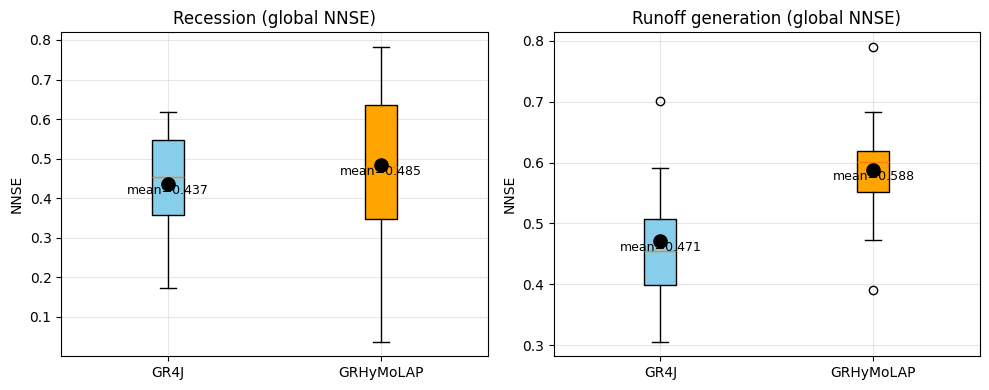

In [19]:
# =========================
# RECESSION SEGMENTS
# =========================
def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):

    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg, dtype=int))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg, dtype=int))

    return segments


# =========================
# RUNOFF GENERATION SEGMENTS
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):

    dQ = np.diff(Q)
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i)
        else:
            if len(current) > 0:
                segments.append(np.array(current, dtype=int))
                current = []

    if len(current) > 0:
        segments.append(np.array(current, dtype=int))

    return segments


# =========================
# NSE / NNSE
# =========================
def nse(sim, obs):
    sim = np.asarray(sim)
    obs = np.asarray(obs)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    if len(obs) < 5:
        return np.nan

    denom = np.sum((obs - np.mean(obs))**2)
    if denom < 1e-12:
        return np.nan

    return 1 - np.sum((sim - obs)**2) / denom


def nnse(sim, obs):
    NSE = nse(sim, obs)
    if np.isnan(NSE):
        return np.nan
    if (2 - NSE) <= 1e-12:
        return np.nan
    return 1 / (2 - NSE)


# =========================
# HELPER: GLOBAL INDICES
# =========================
def segments_to_indices(segments, shift=0):
    if len(segments) == 0:
        return None

    idx = np.concatenate(segments) + shift

    if len(idx) == 0:
        return None

    return np.unique(idx)


# =========================
# STORAGE
# =========================
nnse_rec_gr4j, nnse_rec_hymo = [], []
nnse_run_gr4j, nnse_run_hymo = [], []


# =========================
# LOOP BASINS
# =========================
for station_id in worst_basins:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        # =========================
        # RECESSION
        # =========================
        rec_segments = extract_recession_segments(Q_obs)
        rec_idx = segments_to_indices(rec_segments)

        if rec_idx is not None:
            obs_r = Q_obs[rec_idx]
            gr4j_r = Q_gr4j[rec_idx]
            hymo_r = Q_hymo[rec_idx]

            nnse_rec_gr4j.append(nnse(gr4j_r, obs_r))
            nnse_rec_hymo.append(nnse(hymo_r, obs_r))

        # =========================
        # RUNOFF GENERATION
        # =========================
        run_segments = extract_runoff_generation_segments(Q_obs)
        run_idx = segments_to_indices(run_segments, shift=1)

        if run_idx is not None:
            obs_g = Q_obs[run_idx]
            gr4j_g = Q_gr4j[run_idx]
            hymo_g = Q_hymo[run_idx]

            nnse_run_gr4j.append(nnse(gr4j_g, obs_g))
            nnse_run_hymo.append(nnse(hymo_g, obs_g))

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


def annotate_box(ax, data, x_positions):
    means = [np.nanmean(d) for d in data]
    medians = [np.nanmedian(d) for d in data]

    for x, m, md in zip(x_positions, means, medians):
        ax.scatter(x, m, color='black', s=90, zorder=3)
        ax.text(x, m, f"mean={m:.3f}", ha='center', va='top', fontsize=9)
        #ax.text(x, md, f"med={md:.3f}", ha='center', va='bottom', fontsize=9)


# RECESSION
data1 = [nnse_rec_gr4j, nnse_rec_hymo]

bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp1['boxes'][0].set_facecolor("skyblue")
bp1['boxes'][1].set_facecolor("orange")

axes[0].set_title("Recession (global NNSE)")
axes[0].set_ylabel("NNSE")
axes[0].grid(alpha=0.3)

annotate_box(axes[0], data1, [1, 2])


# RUNOFF
data2 = [nnse_run_gr4j, nnse_run_hymo]

bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp2['boxes'][0].set_facecolor("skyblue")
bp2['boxes'][1].set_facecolor("orange")

axes[1].set_title("Runoff generation (global NNSE)")
axes[1].set_ylabel("NNSE")
axes[1].grid(alpha=0.3)

annotate_box(axes[1], data2, [1, 2])

plt.tight_layout()
plt.show()

Recession and RG dynamics

/tmp/ipykernel_647/2228533961.py:219: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(data,
/tmp/ipykernel_647/2228533961.py:234: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(data,
/tmp/ipykernel_647/2228533961.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(data,
/tmp/ipykernel_647/2228533961.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data,


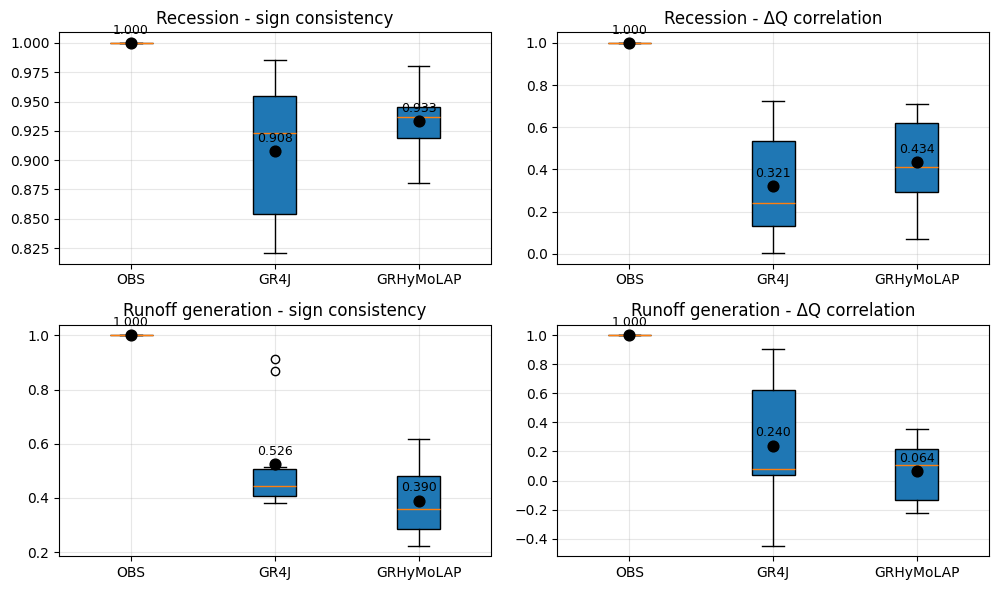

In [20]:
# =========================================================
# 1. SEGMENTS (OBS ONLY)
# =========================================================

def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg))

    return segments


# =========================
# RUNOFF GENERATION
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                segments.append(np.array(current))
                current = []

    if len(current) > 0:
        segments.append(np.array(current))

    return segments


# =========================================================
# 2. METRIC 1 — SIGN CONSISTENCY
# =========================================================

def sign_consistency(Q_obs, Q_mod, segments, regime="recession"):

    violations = 0
    total = 0

    for seg in segments:

        dq_mod = np.diff(Q_mod[seg])
        dq_obs = np.diff(Q_obs[seg])

        total += len(dq_obs)

        if regime == "recession":
            violations += np.sum(dq_mod > 0)   # should decrease
        elif regime == "runoff":
            violations += np.sum(dq_mod < 0)   # should increase
        else:
            raise ValueError("unknown regime")

    if total == 0:
        return np.nan

    return 1 - violations / total


# =========================================================
# 3. METRIC 2 — CORRELATION OF ΔQ
# =========================================================

def deltaQ_correlation(Q_obs, Q_mod, segments):

    obs_all = []
    mod_all = []

    for seg in segments:

        dq_obs = np.diff(Q_obs[seg])
        dq_mod = np.diff(Q_mod[seg])

        obs_all.append(dq_obs)
        mod_all.append(dq_mod)

    if len(obs_all) == 0:
        return np.nan

    obs_all = np.concatenate(obs_all)
    mod_all = np.concatenate(mod_all)

    if len(obs_all) < 5 or len(mod_all) < 5:
        return np.nan

    if np.std(obs_all) < 1e-12 or np.std(mod_all) < 1e-12:
        return np.nan

    return np.corrcoef(obs_all, mod_all)[0, 1]


# =========================================================
# 4. STORAGE
# =========================================================

# RECESSION
sign_rec_obs, sign_rec_gr4j, sign_rec_hymo = [], [], []
c_rec_obs, c_rec_gr4j, c_rec_hymo = [], [], []

# RUNOFF GENERATION
sign_rg_obs, sign_rg_gr4j, sign_rg_hymo = [], [], []
c_rg_obs, c_rg_gr4j, c_rg_hymo = [], [], []


# =========================================================
# 5. LOOP OVER BASINS
# =========================================================

for station_id in worst_basins:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        n = min(len(Q_obs), len(Q_gr4j), len(Q_hymo))

        Q_obs = Q_obs[:n]
        Q_gr4j = Q_gr4j[:n]
        Q_hymo = Q_hymo[:n]

        # =================================================
        # RECESSION
        # =================================================
        rec_segments = extract_recession_segments(Q_obs)

        sign_rec_obs.append(sign_consistency(Q_obs, Q_obs, rec_segments, regime="recession"))
        sign_rec_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rec_segments, regime="recession"))
        sign_rec_hymo.append(sign_consistency(Q_obs, Q_hymo, rec_segments, regime="recession"))

        c_rec_obs.append(deltaQ_correlation(Q_obs, Q_obs, rec_segments))
        c_rec_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rec_segments))
        c_rec_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rec_segments))

        # =================================================
        # RUNOFF GENERATION
        # =================================================
        rg_segments = extract_runoff_generation_segments(Q_obs)

        sign_rg_obs.append(sign_consistency(Q_obs, Q_obs, rg_segments, regime="runoff"))
        sign_rg_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rg_segments, regime="runoff"))
        sign_rg_hymo.append(sign_consistency(Q_obs, Q_hymo, rg_segments, regime="runoff"))

        c_rg_obs.append(deltaQ_correlation(Q_obs, Q_obs, rg_segments))
        c_rg_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rg_segments))
        c_rg_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rg_segments))

    except Exception as e:
        print("Skipped:", station_id, e)


# =========================================================
# 6. HELPER — ADD MEANS ON PLOT
# =========================================================

def add_means(ax, data, x_positions):

    means = [np.nanmean(d) for d in data]

    for x, m in zip(x_positions, means):

        # point moyen
        ax.scatter(x, m, color="black", s=60, zorder=3)

        # petit décalage vertical automatique
        offset = 0.03 * (np.nanmax(data) - np.nanmin(data) + 1e-12)

        ax.text(
            x,
            m + offset,   # 👈 décalage vers le haut
            f"{m:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


# =========================================================
# 7. PLOT
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 6))


# -------------------------
# RECESSION - SIGN
# -------------------------
data = [sign_rec_obs, sign_rec_gr4j, sign_rec_hymo]

axes[0,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,0], data, [1, 2, 3])

axes[0,0].set_title("Recession - sign consistency")
axes[0,0].grid(alpha=0.3)


# -------------------------
# RECESSION - CORR
# -------------------------
data = [c_rec_obs, c_rec_gr4j, c_rec_hymo]

axes[0,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,1], data, [1, 2, 3])

axes[0,1].set_title("Recession - ΔQ correlation")
axes[0,1].grid(alpha=0.3)


# -------------------------
# RUNOFF - SIGN
# -------------------------
data = [sign_rg_obs, sign_rg_gr4j, sign_rg_hymo]

axes[1,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,0], data, [1, 2, 3])

axes[1,0].set_title("Runoff generation - sign consistency")
axes[1,0].grid(alpha=0.3)


# -------------------------
# RUNOFF - CORR
# -------------------------
data = [c_rg_obs, c_rg_gr4j, c_rg_hymo]

axes[1,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,1], data, [1, 2, 3])

axes[1,1].set_title("Runoff generation - ΔQ correlation")
axes[1,1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

##Low RR

Select 10 basins where GRHyMoLAP beats GR4J the most in the low RR class

In [21]:
import numpy as np
import pandas as pd

rows = []

# =========================
# LOOP
# =========================
for station_id in dry_stations:

    try:
        nse_gr4j = results_GR4J[station_id]["NSE_val"]
        nse_hymo = results_GRHyMoLAP[station_id]["NSE_val"]

        if not (np.isfinite(nse_gr4j) and np.isfinite(nse_hymo)):
            continue

        # NNSE only
        nnse_gr4j = NNSE(nse_gr4j)
        nnse_hymo = NNSE(nse_hymo)

        rows.append({
            "Station": station_id,
            "NNSE_GR4J": float(nnse_gr4j),
            "NNSE_GRHyMoLAP": float(nnse_hymo)
        })

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# DATAFRAME
# =========================
df = pd.DataFrame(rows)

# =========================
# TOP 10 (based on improvement)
# =========================
df["NNSE_Gain"] = df["NNSE_GRHyMoLAP"] - df["NNSE_GR4J"]

df_best = df.sort_values(by="NNSE_Gain", ascending=False).head(10)

best_basins_Low_RR = df_best["Station"].tolist()

# =========================
# MEAN NNSE (TOP 10)
# =========================
mean_nnse_gr4j = df_best["NNSE_GR4J"].mean()
mean_nnse_hymo = df_best["NNSE_GRHyMoLAP"].mean()

# =========================
# PRINT TOP 10 TABLE
# =========================
print("\nTop 10 basins where GRHyMoLAP improves NNSE the most (dry basins):\n")

print(
    df_best[["Station", "NNSE_GR4J", "NNSE_GRHyMoLAP"]]
    .to_string(index=False, float_format="%.3f")
)

# =========================
# PRINT MEANS
# =========================
print("\n=== Mean NNSE (Top 10 dry basins) ===")
print(f"GR4J       : {mean_nnse_gr4j:.3f}")
print(f"GRHyMoLAP  : {mean_nnse_hymo:.3f}")


Top 10 basins where GRHyMoLAP improves NNSE the most (dry basins):

 Station  NNSE_GR4J  NNSE_GRHyMoLAP
G0060005      0.275           0.610
A2390523      0.360           0.651
  408200      0.327           0.535
 424201A      0.478           0.660
  614044      0.422           0.594
  424002      0.478           0.612
  616065      0.513           0.645
A0030501      0.539           0.625
  606002      0.688           0.764
  616013      0.638           0.698

=== Mean NNSE (Top 10 dry basins) ===
GR4J       : 0.472
GRHyMoLAP  : 0.640


/tmp/ipykernel_647/2668554084.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
/tmp/ipykernel_647/2668554084.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)


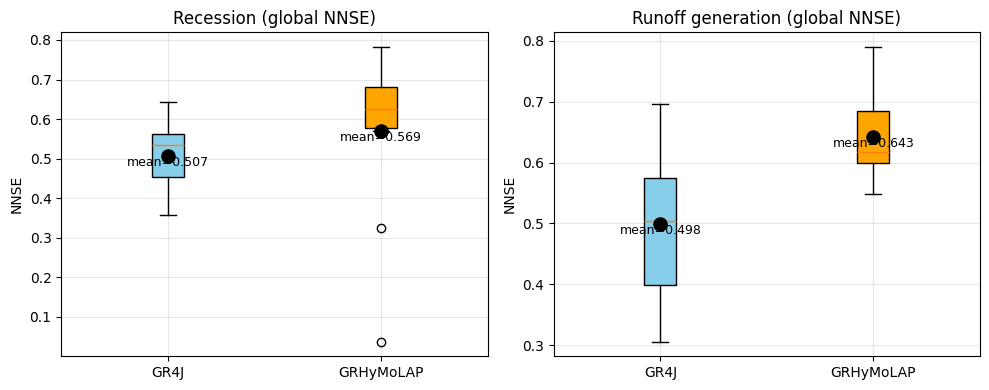

In [22]:
# =========================
# RECESSION SEGMENTS
# =========================
def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):

    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg, dtype=int))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg, dtype=int))

    return segments


# =========================
# RUNOFF GENERATION SEGMENTS
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):

    dQ = np.diff(Q)
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i)
        else:
            if len(current) > 0:
                segments.append(np.array(current, dtype=int))
                current = []

    if len(current) > 0:
        segments.append(np.array(current, dtype=int))

    return segments


# =========================
# NSE / NNSE
# =========================
def nse(sim, obs):
    sim = np.asarray(sim)
    obs = np.asarray(obs)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    if len(obs) < 5:
        return np.nan

    denom = np.sum((obs - np.mean(obs))**2)
    if denom < 1e-12:
        return np.nan

    return 1 - np.sum((sim - obs)**2) / denom


def nnse(sim, obs):
    NSE = nse(sim, obs)
    if np.isnan(NSE):
        return np.nan
    if (2 - NSE) <= 1e-12:
        return np.nan
    return 1 / (2 - NSE)


# =========================
# HELPER: GLOBAL INDICES
# =========================
def segments_to_indices(segments, shift=0):
    if len(segments) == 0:
        return None

    idx = np.concatenate(segments) + shift

    if len(idx) == 0:
        return None

    return np.unique(idx)


# =========================
# STORAGE
# =========================
nnse_rec_gr4j, nnse_rec_hymo = [], []
nnse_run_gr4j, nnse_run_hymo = [], []


# =========================
# LOOP BASINS
# =========================
for station_id in best_basins_Low_RR:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        # =========================
        # RECESSION
        # =========================
        rec_segments = extract_recession_segments(Q_obs)
        rec_idx = segments_to_indices(rec_segments)

        if rec_idx is not None:
            obs_r = Q_obs[rec_idx]
            gr4j_r = Q_gr4j[rec_idx]
            hymo_r = Q_hymo[rec_idx]

            nnse_rec_gr4j.append(nnse(gr4j_r, obs_r))
            nnse_rec_hymo.append(nnse(hymo_r, obs_r))

        # =========================
        # RUNOFF GENERATION
        # =========================
        run_segments = extract_runoff_generation_segments(Q_obs)
        run_idx = segments_to_indices(run_segments, shift=1)

        if run_idx is not None:
            obs_g = Q_obs[run_idx]
            gr4j_g = Q_gr4j[run_idx]
            hymo_g = Q_hymo[run_idx]

            nnse_run_gr4j.append(nnse(gr4j_g, obs_g))
            nnse_run_hymo.append(nnse(hymo_g, obs_g))

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


def annotate_box(ax, data, x_positions):
    means = [np.nanmean(d) for d in data]
    medians = [np.nanmedian(d) for d in data]

    for x, m, md in zip(x_positions, means, medians):
        ax.scatter(x, m, color='black', s=90, zorder=3)
        ax.text(x, m, f"mean={m:.3f}", ha='center', va='top', fontsize=9)
        #ax.text(x, md, f"med={md:.3f}", ha='center', va='bottom', fontsize=9)


# RECESSION
data1 = [nnse_rec_gr4j, nnse_rec_hymo]

bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp1['boxes'][0].set_facecolor("skyblue")
bp1['boxes'][1].set_facecolor("orange")

axes[0].set_title("Recession (global NNSE)")
axes[0].set_ylabel("NNSE")
axes[0].grid(alpha=0.3)

annotate_box(axes[0], data1, [1, 2])


# RUNOFF
data2 = [nnse_run_gr4j, nnse_run_hymo]

bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp2['boxes'][0].set_facecolor("skyblue")
bp2['boxes'][1].set_facecolor("orange")

axes[1].set_title("Runoff generation (global NNSE)")
axes[1].set_ylabel("NNSE")
axes[1].grid(alpha=0.3)

annotate_box(axes[1], data2, [1, 2])

plt.tight_layout()
plt.show()

/tmp/ipykernel_647/2757688285.py:219: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(data,
/tmp/ipykernel_647/2757688285.py:234: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(data,
/tmp/ipykernel_647/2757688285.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(data,
/tmp/ipykernel_647/2757688285.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data,


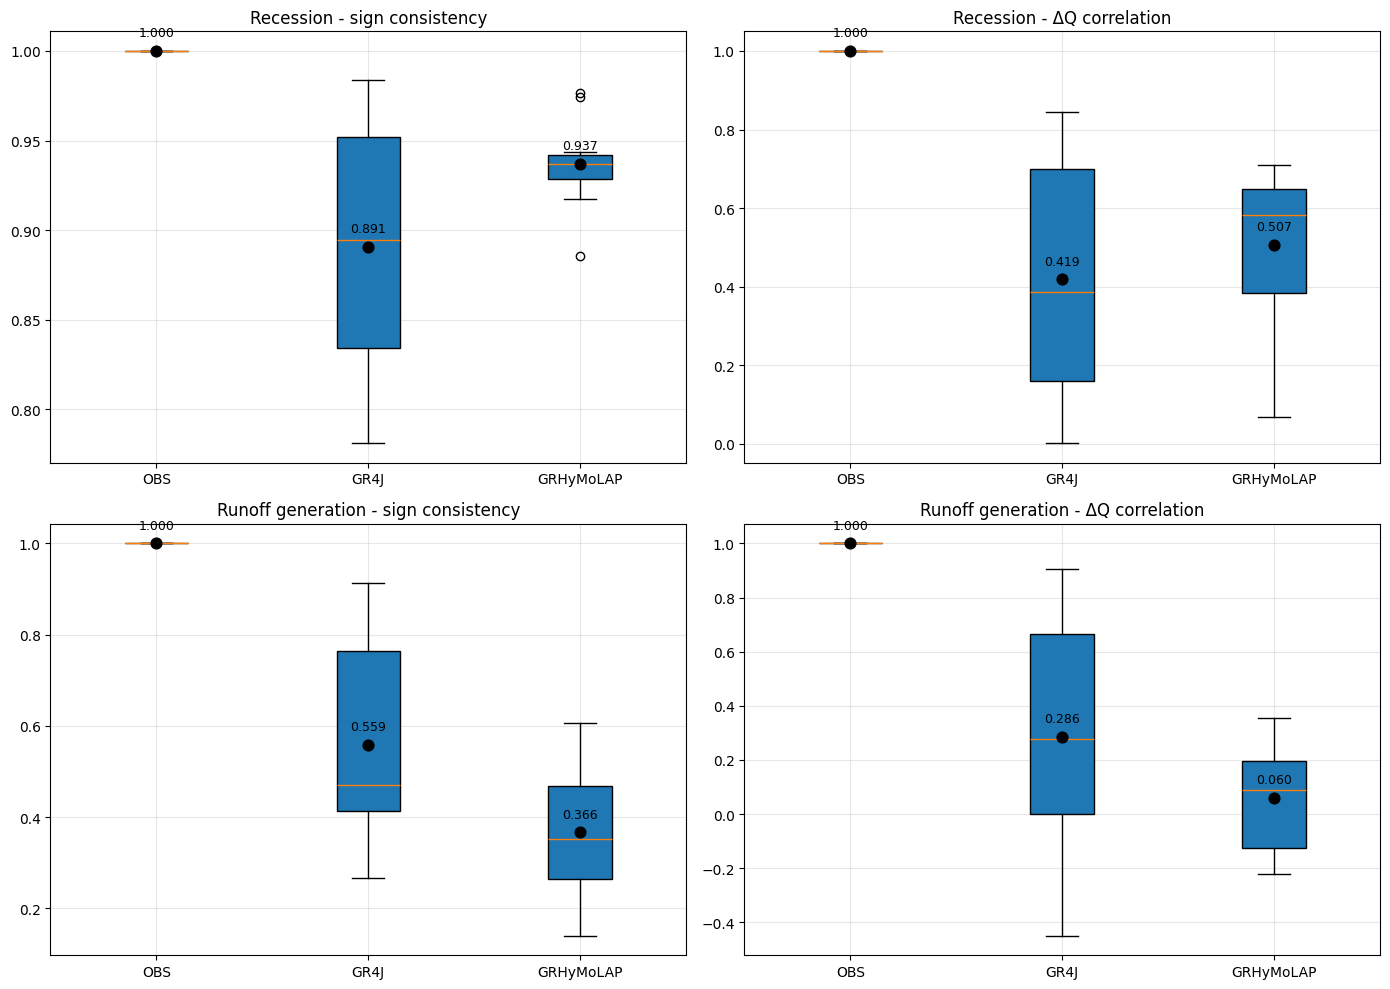

In [23]:
# =========================================================
# 1. SEGMENTS (OBS ONLY)
# =========================================================

def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg))

    return segments


# =========================
# RUNOFF GENERATION
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                segments.append(np.array(current))
                current = []

    if len(current) > 0:
        segments.append(np.array(current))

    return segments


# =========================================================
# 2. METRIC 1 — SIGN CONSISTENCY
# =========================================================

def sign_consistency(Q_obs, Q_mod, segments, regime="recession"):

    violations = 0
    total = 0

    for seg in segments:

        dq_mod = np.diff(Q_mod[seg])
        dq_obs = np.diff(Q_obs[seg])

        total += len(dq_obs)

        if regime == "recession":
            violations += np.sum(dq_mod > 0)   # should decrease
        elif regime == "runoff":
            violations += np.sum(dq_mod < 0)   # should increase
        else:
            raise ValueError("unknown regime")

    if total == 0:
        return np.nan

    return 1 - violations / total


# =========================================================
# 3. METRIC 2 — CORRELATION OF ΔQ
# =========================================================

def deltaQ_correlation(Q_obs, Q_mod, segments):

    obs_all = []
    mod_all = []

    for seg in segments:

        dq_obs = np.diff(Q_obs[seg])
        dq_mod = np.diff(Q_mod[seg])

        obs_all.append(dq_obs)
        mod_all.append(dq_mod)

    if len(obs_all) == 0:
        return np.nan

    obs_all = np.concatenate(obs_all)
    mod_all = np.concatenate(mod_all)

    if len(obs_all) < 5 or len(mod_all) < 5:
        return np.nan

    if np.std(obs_all) < 1e-12 or np.std(mod_all) < 1e-12:
        return np.nan

    return np.corrcoef(obs_all, mod_all)[0, 1]


# =========================================================
# 4. STORAGE
# =========================================================

# RECESSION
sign_rec_obs, sign_rec_gr4j, sign_rec_hymo = [], [], []
c_rec_obs, c_rec_gr4j, c_rec_hymo = [], [], []

# RUNOFF GENERATION
sign_rg_obs, sign_rg_gr4j, sign_rg_hymo = [], [], []
c_rg_obs, c_rg_gr4j, c_rg_hymo = [], [], []


# =========================================================
# 5. LOOP OVER BASINS
# =========================================================

for station_id in best_basins_Low_RR:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        n = min(len(Q_obs), len(Q_gr4j), len(Q_hymo))

        Q_obs = Q_obs[:n]
        Q_gr4j = Q_gr4j[:n]
        Q_hymo = Q_hymo[:n]

        # =================================================
        # RECESSION
        # =================================================
        rec_segments = extract_recession_segments(Q_obs)

        sign_rec_obs.append(sign_consistency(Q_obs, Q_obs, rec_segments, regime="recession"))
        sign_rec_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rec_segments, regime="recession"))
        sign_rec_hymo.append(sign_consistency(Q_obs, Q_hymo, rec_segments, regime="recession"))

        c_rec_obs.append(deltaQ_correlation(Q_obs, Q_obs, rec_segments))
        c_rec_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rec_segments))
        c_rec_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rec_segments))

        # =================================================
        # RUNOFF GENERATION
        # =================================================
        rg_segments = extract_runoff_generation_segments(Q_obs)

        sign_rg_obs.append(sign_consistency(Q_obs, Q_obs, rg_segments, regime="runoff"))
        sign_rg_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rg_segments, regime="runoff"))
        sign_rg_hymo.append(sign_consistency(Q_obs, Q_hymo, rg_segments, regime="runoff"))

        c_rg_obs.append(deltaQ_correlation(Q_obs, Q_obs, rg_segments))
        c_rg_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rg_segments))
        c_rg_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rg_segments))

    except Exception as e:
        print("Skipped:", station_id, e)


# =========================================================
# 6. HELPER — ADD MEANS ON PLOT
# =========================================================

def add_means(ax, data, x_positions):

    means = [np.nanmean(d) for d in data]

    for x, m in zip(x_positions, means):

        # point moyen
        ax.scatter(x, m, color="black", s=60, zorder=3)

        # petit décalage vertical automatique
        offset = 0.03 * (np.nanmax(data) - np.nanmin(data) + 1e-12)

        ax.text(
            x,
            m + offset,   # 👈 décalage vers le haut
            f"{m:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


# =========================================================
# 7. PLOT
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# -------------------------
# RECESSION - SIGN
# -------------------------
data = [sign_rec_obs, sign_rec_gr4j, sign_rec_hymo]

axes[0,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,0], data, [1, 2, 3])

axes[0,0].set_title("Recession - sign consistency")
axes[0,0].grid(alpha=0.3)


# -------------------------
# RECESSION - CORR
# -------------------------
data = [c_rec_obs, c_rec_gr4j, c_rec_hymo]

axes[0,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,1], data, [1, 2, 3])

axes[0,1].set_title("Recession - ΔQ correlation")
axes[0,1].grid(alpha=0.3)


# -------------------------
# RUNOFF - SIGN
# -------------------------
data = [sign_rg_obs, sign_rg_gr4j, sign_rg_hymo]

axes[1,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,0], data, [1, 2, 3])

axes[1,0].set_title("Runoff generation - sign consistency")
axes[1,0].grid(alpha=0.3)


# -------------------------
# RUNOFF - CORR
# -------------------------
data = [c_rg_obs, c_rg_gr4j, c_rg_hymo]

axes[1,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,1], data, [1, 2, 3])

axes[1,1].set_title("Runoff generation - ΔQ correlation")
axes[1,1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

## High RR

Select 10 basins where GRHyMoLAP beats GR4J the most in the highest RR class

In [24]:
import numpy as np
import pandas as pd

rows = []

# =========================
# LOOP OVER WET STATIONS
# =========================
for station_id in wet_stations:

    try:
        nse_gr4j = results_GR4J[station_id]["NSE_val"]
        nse_hymo = results_GRHyMoLAP[station_id]["NSE_val"]

        if not (np.isfinite(nse_gr4j) and np.isfinite(nse_hymo)):
            continue

        # NNSE only
        nnse_gr4j = NNSE(nse_gr4j)
        nnse_hymo = NNSE(nse_hymo)

        rows.append({
            "Station": station_id,
            "NNSE_GR4J": float(nnse_gr4j),
            "NNSE_GRHyMoLAP": float(nnse_hymo)
        })

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# DATAFRAME
# =========================
df = pd.DataFrame(rows)

# =========================
# Compute gain & select TOP 10 improvement
# =========================
df["NNSE_Gain"] = df["NNSE_GRHyMoLAP"] - df["NNSE_GR4J"]
df_best = df.sort_values(by="NNSE_Gain", ascending=False).head(10)

best_basins_High_RR = df_best["Station"].tolist()

# =========================
# MEAN NNSE (TOP 10)
# =========================
mean_nnse_gr4j = df_best["NNSE_GR4J"].mean()
mean_nnse_hymo = df_best["NNSE_GRHyMoLAP"].mean()

# =========================
# PRINT TOP 10 TABLE
# =========================
print("\nTop 10 wet basins where GRHyMoLAP improves NNSE the most:\n")
print(
    df_best[["Station", "NNSE_GR4J", "NNSE_GRHyMoLAP"]]
    .to_string(index=False, float_format="%.3f")
)

# =========================
# PRINT MEANS
# =========================
print("\n=== Mean NNSE (Top 10 wet basins) ===")
print(f"GR4J       : {mean_nnse_gr4j:.3f}")
print(f"GRHyMoLAP  : {mean_nnse_hymo:.3f}")


Top 10 wet basins where GRHyMoLAP improves NNSE the most:

Station  NNSE_GR4J  NNSE_GRHyMoLAP
 312061      0.809           0.875
 401216      0.704           0.762
 401212      0.775           0.817
 304497      0.802           0.838
 405218      0.783           0.815
 315450      0.802           0.825
122004A      0.845           0.864
 304499      0.774           0.785
922101B      0.807           0.811
 308799      0.842           0.846

=== Mean NNSE (Top 10 wet basins) ===
GR4J       : 0.794
GRHyMoLAP  : 0.824


/tmp/ipykernel_647/2563350609.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
/tmp/ipykernel_647/2563350609.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)


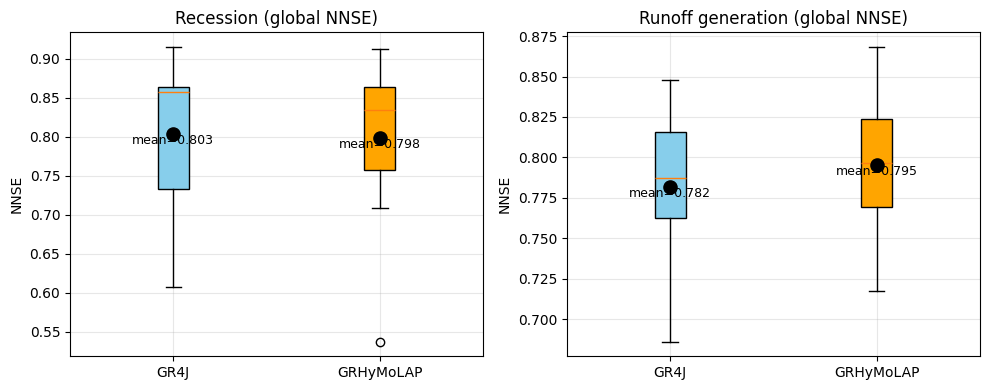

In [25]:
# =========================
# RECESSION SEGMENTS
# =========================
def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):

    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg, dtype=int))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg, dtype=int))

    return segments


# =========================
# RUNOFF GENERATION SEGMENTS
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):

    dQ = np.diff(Q)
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i)
        else:
            if len(current) > 0:
                segments.append(np.array(current, dtype=int))
                current = []

    if len(current) > 0:
        segments.append(np.array(current, dtype=int))

    return segments


# =========================
# NSE / NNSE
# =========================
def nse(sim, obs):
    sim = np.asarray(sim)
    obs = np.asarray(obs)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    if len(obs) < 5:
        return np.nan

    denom = np.sum((obs - np.mean(obs))**2)
    if denom < 1e-12:
        return np.nan

    return 1 - np.sum((sim - obs)**2) / denom


def nnse(sim, obs):
    NSE = nse(sim, obs)
    if np.isnan(NSE):
        return np.nan
    if (2 - NSE) <= 1e-12:
        return np.nan
    return 1 / (2 - NSE)


# =========================
# HELPER: GLOBAL INDICES
# =========================
def segments_to_indices(segments, shift=0):
    if len(segments) == 0:
        return None

    idx = np.concatenate(segments) + shift

    if len(idx) == 0:
        return None

    return np.unique(idx)


# =========================
# STORAGE
# =========================
nnse_rec_gr4j, nnse_rec_hymo = [], []
nnse_run_gr4j, nnse_run_hymo = [], []


# =========================
# LOOP BASINS
# =========================
for station_id in best_basins_High_RR:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        # =========================
        # RECESSION
        # =========================
        rec_segments = extract_recession_segments(Q_obs)
        rec_idx = segments_to_indices(rec_segments)

        if rec_idx is not None:
            obs_r = Q_obs[rec_idx]
            gr4j_r = Q_gr4j[rec_idx]
            hymo_r = Q_hymo[rec_idx]

            nnse_rec_gr4j.append(nnse(gr4j_r, obs_r))
            nnse_rec_hymo.append(nnse(hymo_r, obs_r))

        # =========================
        # RUNOFF GENERATION
        # =========================
        run_segments = extract_runoff_generation_segments(Q_obs)
        run_idx = segments_to_indices(run_segments, shift=1)

        if run_idx is not None:
            obs_g = Q_obs[run_idx]
            gr4j_g = Q_gr4j[run_idx]
            hymo_g = Q_hymo[run_idx]

            nnse_run_gr4j.append(nnse(gr4j_g, obs_g))
            nnse_run_hymo.append(nnse(hymo_g, obs_g))

    except Exception as e:
        print(f"Skipped {station_id}:", e)


# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


def annotate_box(ax, data, x_positions):
    means = [np.nanmean(d) for d in data]
    medians = [np.nanmedian(d) for d in data]

    for x, m, md in zip(x_positions, means, medians):
        ax.scatter(x, m, color='black', s=90, zorder=3)
        ax.text(x, m, f"mean={m:.3f}", ha='center', va='top', fontsize=9)
        #ax.text(x, md, f"med={md:.3f}", ha='center', va='bottom', fontsize=9)


# RECESSION
data1 = [nnse_rec_gr4j, nnse_rec_hymo]

bp1 = axes[0].boxplot(data1, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp1['boxes'][0].set_facecolor("skyblue")
bp1['boxes'][1].set_facecolor("orange")

axes[0].set_title("Recession (global NNSE)")
axes[0].set_ylabel("NNSE")
axes[0].grid(alpha=0.3)

annotate_box(axes[0], data1, [1, 2])


# RUNOFF
data2 = [nnse_run_gr4j, nnse_run_hymo]

bp2 = axes[1].boxplot(data2, labels=["GR4J", "GRHyMoLAP"], patch_artist=True)
bp2['boxes'][0].set_facecolor("skyblue")
bp2['boxes'][1].set_facecolor("orange")

axes[1].set_title("Runoff generation (global NNSE)")
axes[1].set_ylabel("NNSE")
axes[1].grid(alpha=0.3)

annotate_box(axes[1], data2, [1, 2])

plt.tight_layout()
plt.show()

/tmp/ipykernel_647/1858191255.py:219: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(data,
/tmp/ipykernel_647/1858191255.py:234: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(data,
/tmp/ipykernel_647/1858191255.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(data,
/tmp/ipykernel_647/1858191255.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data,


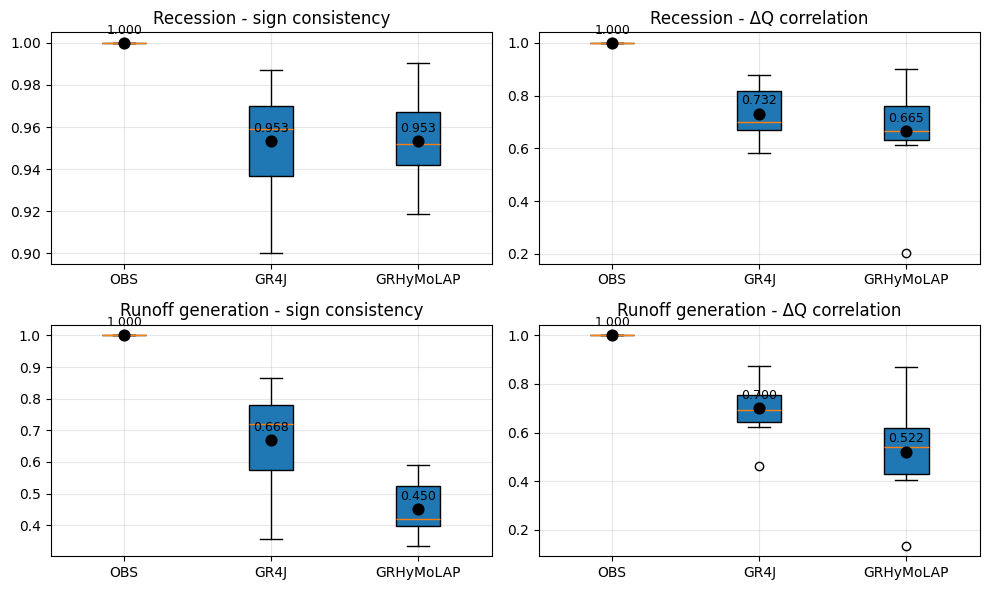

In [26]:

# =========================================================
# 1. SEGMENTS (OBS ONLY)
# =========================================================

def extract_recession_segments(Q, eps=0.0, remove_first_days=2, min_length=7):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_recession = dQ < eps

    segments = []
    current = []

    for i, flag in enumerate(is_recession):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                seg = current[remove_first_days:]
                if len(seg) >= min_length:
                    segments.append(np.array(seg))
                current = []

    if len(current) > 0:
        seg = current[remove_first_days:]
        if len(seg) >= min_length:
            segments.append(np.array(seg))

    return segments


# =========================
# RUNOFF GENERATION
# =========================
def extract_runoff_generation_segments(Q, eps=0.0):
    Q = np.asarray(Q)
    dQ = Q[1:] - Q[:-1]
    is_runoff = dQ > eps

    segments = []
    current = []

    for i, flag in enumerate(is_runoff):
        if flag:
            current.append(i + 1)
        else:
            if len(current) > 0:
                segments.append(np.array(current))
                current = []

    if len(current) > 0:
        segments.append(np.array(current))

    return segments


# =========================================================
# 2. METRIC 1 — SIGN CONSISTENCY
# =========================================================

def sign_consistency(Q_obs, Q_mod, segments, regime="recession"):

    violations = 0
    total = 0

    for seg in segments:

        dq_mod = np.diff(Q_mod[seg])
        dq_obs = np.diff(Q_obs[seg])

        total += len(dq_obs)

        if regime == "recession":
            violations += np.sum(dq_mod > 0)   # should decrease
        elif regime == "runoff":
            violations += np.sum(dq_mod < 0)   # should increase
        else:
            raise ValueError("unknown regime")

    if total == 0:
        return np.nan

    return 1 - violations / total


# =========================================================
# 3. METRIC 2 — CORRELATION OF ΔQ
# =========================================================

def deltaQ_correlation(Q_obs, Q_mod, segments):

    obs_all = []
    mod_all = []

    for seg in segments:

        dq_obs = np.diff(Q_obs[seg])
        dq_mod = np.diff(Q_mod[seg])

        obs_all.append(dq_obs)
        mod_all.append(dq_mod)

    if len(obs_all) == 0:
        return np.nan

    obs_all = np.concatenate(obs_all)
    mod_all = np.concatenate(mod_all)

    if len(obs_all) < 5 or len(mod_all) < 5:
        return np.nan

    if np.std(obs_all) < 1e-12 or np.std(mod_all) < 1e-12:
        return np.nan

    return np.corrcoef(obs_all, mod_all)[0, 1]


# =========================================================
# 4. STORAGE
# =========================================================

# RECESSION
sign_rec_obs, sign_rec_gr4j, sign_rec_hymo = [], [], []
c_rec_obs, c_rec_gr4j, c_rec_hymo = [], [], []

# RUNOFF GENERATION
sign_rg_obs, sign_rg_gr4j, sign_rg_hymo = [], [], []
c_rg_obs, c_rg_gr4j, c_rg_hymo = [], [], []


# =========================================================
# 5. LOOP OVER BASINS
# =========================================================

for station_id in best_basins_High_RR:

    try:
        Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)[b1:]
        Q_gr4j = results_GR4J[station_id]["Qsim_val"]
        Q_hymo = results_GRHyMoLAP[station_id]["Qsim_val"]

        n = min(len(Q_obs), len(Q_gr4j), len(Q_hymo))

        Q_obs = Q_obs[:n]
        Q_gr4j = Q_gr4j[:n]
        Q_hymo = Q_hymo[:n]

        # =================================================
        # RECESSION
        # =================================================
        rec_segments = extract_recession_segments(Q_obs)

        sign_rec_obs.append(sign_consistency(Q_obs, Q_obs, rec_segments, regime="recession"))
        sign_rec_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rec_segments, regime="recession"))
        sign_rec_hymo.append(sign_consistency(Q_obs, Q_hymo, rec_segments, regime="recession"))

        c_rec_obs.append(deltaQ_correlation(Q_obs, Q_obs, rec_segments))
        c_rec_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rec_segments))
        c_rec_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rec_segments))

        # =================================================
        # RUNOFF GENERATION
        # =================================================
        rg_segments = extract_runoff_generation_segments(Q_obs)

        sign_rg_obs.append(sign_consistency(Q_obs, Q_obs, rg_segments, regime="runoff"))
        sign_rg_gr4j.append(sign_consistency(Q_obs, Q_gr4j, rg_segments, regime="runoff"))
        sign_rg_hymo.append(sign_consistency(Q_obs, Q_hymo, rg_segments, regime="runoff"))

        c_rg_obs.append(deltaQ_correlation(Q_obs, Q_obs, rg_segments))
        c_rg_gr4j.append(deltaQ_correlation(Q_obs, Q_gr4j, rg_segments))
        c_rg_hymo.append(deltaQ_correlation(Q_obs, Q_hymo, rg_segments))

    except Exception as e:
        print("Skipped:", station_id, e)


# =========================================================
# 6. HELPER — ADD MEANS ON PLOT
# =========================================================

def add_means(ax, data, x_positions):

    means = [np.nanmean(d) for d in data]

    for x, m in zip(x_positions, means):

        # mean point
        ax.scatter(x, m, color="black", s=60, zorder=3)

        offset = 0.03 * (np.nanmax(data) - np.nanmin(data) + 1e-12)

        ax.text(
            x,
            m + offset,
            f"{m:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


# =========================================================
# 7. PLOT
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 6))


# -------------------------
# RECESSION - SIGN
# -------------------------
data = [sign_rec_obs, sign_rec_gr4j, sign_rec_hymo]

axes[0,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,0], data, [1, 2, 3])

axes[0,0].set_title("Recession - sign consistency")
axes[0,0].grid(alpha=0.3)


# -------------------------
# RECESSION - CORR
# -------------------------
data = [c_rec_obs, c_rec_gr4j, c_rec_hymo]

axes[0,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[0,1], data, [1, 2, 3])

axes[0,1].set_title("Recession - ΔQ correlation")
axes[0,1].grid(alpha=0.3)


# -------------------------
# RUNOFF - SIGN
# -------------------------
data = [sign_rg_obs, sign_rg_gr4j, sign_rg_hymo]

axes[1,0].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,0], data, [1, 2, 3])

axes[1,0].set_title("Runoff generation - sign consistency")
axes[1,0].grid(alpha=0.3)


# -------------------------
# RUNOFF - CORR
# -------------------------
data = [c_rg_obs, c_rg_gr4j, c_rg_hymo]

axes[1,1].boxplot(data,
                  labels=["OBS", "GR4J", "GRHyMoLAP"],
                  patch_artist=True)

add_means(axes[1,1], data, [1, 2, 3])

axes[1,1].set_title("Runoff generation - ΔQ correlation")
axes[1,1].grid(alpha=0.3)


plt.tight_layout()
plt.show()